# Proyecto 2 — Modelado, Ajuste y Evaluación

## Reto #11: Predicción de compradores recurrentes

**CC3084 – Data Science | Universidad del Valle de Guatemala | Semestre II – 2026**

---

Este notebook corresponde al **paso 4** de la fase de resultados. Usa las 64 variables y la partición construidas en `02_ingenieria_variables.ipynb` para:

1. Definir el preprocesamiento de cada algoritmo dentro de un `Pipeline`, incluyendo la **tasa de recompra del vendedor** (*target encoding*) calculada sin fuga.
2. Ajustar los hiperparámetros de **Regresión Logística**, **Random Forest** y **LightGBM** con búsqueda aleatoria sobre los 5 pliegues de validación cruzada, y comparar contra su configuración por defecto.
3. Elegir el umbral de decisión de cada modelo con predicciones fuera de pliegue.
4. Evaluar una sola vez en el conjunto de prueba reservado, junto con un **ensamble** de los tres modelos.
5. Comparar los modelos (efectividad, errores, tiempos) con gráficas estáticas y guardar los modelos para la aplicación.

**Métrica principal**: AUC-ROC. **Complementarias**: AUC-PR, precisión, recall, F1, matriz de confusión, captura de recurrentes en el 10 % con mayor puntaje y tiempos de cómputo.

## 1. Configuración

In [1]:
from pathlib import Path
import json
import time
import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
                             confusion_matrix, f1_score, precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold, cross_val_predict,
                                     cross_validate)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler, TargetEncoder

warnings.filterwarnings('ignore')
SEED = 42


def a_json(o):
    """Convierte tipos de NumPy a tipos nativos para json."""
    return o.item() if hasattr(o, 'item') else str(o)
np.random.seed(SEED)


def _find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'data' / 'data_format1').exists():
            return candidate
    return current


PROJECT_ROOT = _find_project_root()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR = PROJECT_ROOT / 'outputs' / 'figures'
TAB_DIR = PROJECT_ROOT / 'outputs' / 'tables'
MODEL_DIR = PROJECT_ROOT / 'outputs' / 'models'
for d in (FIG_DIR, TAB_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
                     'font.size': 11, 'axes.titlesize': 13})
sns.set_style('whitegrid')

# Paleta Okabe-Ito (apta para daltonismo); un color fijo por modelo en todo el proyecto
MODELOS = ['Regresión Logística', 'Random Forest', 'LightGBM', 'Ensamble']
COLORES = {'Regresión Logística': '#0072B2', 'Random Forest': '#009E73',
           'LightGBM': '#D55E00', 'Ensamble': '#CC79A7'}
CLAVE = {'Regresión Logística': 'lr', 'Random Forest': 'rf', 'LightGBM': 'lgbm', 'Ensamble': 'ens'}
print(f'Núcleos disponibles: {__import__("os").cpu_count()}')

Núcleos disponibles: 16


## 2. Datos

Se usan las tablas generadas por `02_ingenieria_variables.ipynb`. El conjunto de entrenamiento (80 %) se usa para ajustar y elegir el umbral; el de prueba (20 %) solo para la evaluación final.

In [2]:
df = pd.read_parquet(PROCESSED_DIR / 'features_train.parquet')

CAT = ['age_range', 'gender']
NO_FEATURES = ['user_id', 'label', 'split', 'cv_fold']
NUM = [c for c in df.columns if c not in NO_FEATURES + CAT + ['merchant_id']]
FEATURES = NUM + CAT + ['merchant_id']
assert (df[NUM] >= 0).all().all(), 'Hay variables numéricas negativas (log1p no aplicaría)'

train = df[df['split'] == 'train'].reset_index(drop=True)
test = df[df['split'] == 'test'].reset_index(drop=True)
X_train, y_train = train[FEATURES], train['label'].to_numpy()
X_test, y_test = test[FEATURES], test['label'].to_numpy()

# Pliegues predefinidos (agrupados por usuario, estratificados), construidos en el notebook 02
FOLDS = [(np.where(train['cv_fold'] != f)[0], np.where(train['cv_fold'] == f)[0]) for f in range(5)]

print(f'Entrenamiento: {X_train.shape[0]:,} pares | positivos: {y_train.mean():.4f}')
print(f'Prueba:        {X_test.shape[0]:,} pares | positivos: {y_test.mean():.4f}')
print(f'Variables de entrada: {len(NUM)} numéricas + {len(CAT)} categóricas + merchant_id (target encoding)')
print(f'Tamaño de cada pliegue de validación: {[len(v) for _, v in FOLDS]}')

Entrenamiento: 208,691 pares | positivos: 0.0612
Prueba:        52,173 pares | positivos: 0.0611
Variables de entrada: 62 numéricas + 2 categóricas + merchant_id (target encoding)
Tamaño de cada pliegue de validación: [41739, 41737, 41738, 41739, 41738]


## 3. Líneas base de referencia

Antes de entrenar se calculan dos referencias en el conjunto de prueba:
- **Clasificador aleatorio**: AUC-ROC = 0.5 y AUC-PR = prevalencia.
- **Mejor variable individual** del notebook 02 (`m_repeat_buyer_rate_log`) usada directamente como puntaje.

Un modelo útil debe superar claramente a ambas.

In [3]:
base_prev = y_test.mean()
base_var_auc = roc_auc_score(y_test, X_test['m_repeat_buyer_rate_log'])
base_var_ap = average_precision_score(y_test, X_test['m_repeat_buyer_rate_log'])
print(f'Aleatorio:                     AUC-ROC = 0.500 | AUC-PR = {base_prev:.4f}')
print(f'm_repeat_buyer_rate_log sola:  AUC-ROC = {base_var_auc:.4f} | AUC-PR = {base_var_ap:.4f}')

Aleatorio:                     AUC-ROC = 0.500 | AUC-PR = 0.0611
m_repeat_buyer_rate_log sola:  AUC-ROC = 0.6139 | AUC-PR = 0.0957


## 4. Preprocesamiento dentro de cada `Pipeline`

Todo el preprocesamiento se ajusta **solo con los datos de entrenamiento de cada pliegue**, porque vive dentro del `Pipeline`:

| Paso | Regresión Logística | Random Forest y LightGBM |
|---|---|---|
| Variables numéricas (62) | `log1p` + estandarización (reduce el sesgo documentado en el EDA) | Sin transformar (los árboles son invariantes a transformaciones monótonas) |
| Edad y género | *One-hot* | Códigos ordinales (0–7 y 0–2) |
| `merchant_id` | *Target encoding* + estandarización | *Target encoding* |

**Target encoding sin fuga**: `TargetEncoder` de scikit-learn reemplaza `merchant_id` por la tasa de recompra del vendedor, suavizada hacia la media global. En `fit_transform` usa **ajuste cruzado** interno (5 pliegues): cada fila recibe la tasa calculada sin su propia etiqueta. En `transform` (validación, prueba, aplicación) usa la tasa calculada con todo el entrenamiento. Así, dentro de la validación cruzada, la etiqueta de un par nunca participa en su propia variable.

In [4]:
def target_encoder():
    return TargetEncoder(target_type='binary', cv=StratifiedKFold(5, shuffle=True, random_state=SEED))


def preprocesador(tipo):
    if tipo == 'lineal':
        return ColumnTransformer([
            ('num', make_pipeline(FunctionTransformer(np.log1p, feature_names_out='one-to-one'),
                                  StandardScaler()), NUM),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT),
            ('te', make_pipeline(target_encoder(), StandardScaler()), ['merchant_id']),
        ])
    return ColumnTransformer([
        ('num', 'passthrough', NUM + CAT),
        ('te', target_encoder(), ['merchant_id']),
    ])


def pipeline(tipo, modelo):
    return Pipeline([('prep', preprocesador(tipo)), ('model', modelo)])


# Verificación: el target encoding de entrenamiento es fuera de pliegue
te = target_encoder()
te_fit = te.fit_transform(X_train[['merchant_id']], y_train).ravel()
te_full = te.transform(X_train[['merchant_id']]).ravel()
print(f'Correlación TE fuera de pliegue vs. TE completo: {np.corrcoef(te_fit, te_full)[0, 1]:.3f} (< 1 ⇒ distintos)')
print(f"AUC en entrenamiento: TE fuera de pliegue {roc_auc_score(y_train, te_fit):.4f} | "
      f"TE con fuga {roc_auc_score(y_train, te_full):.4f}")
print(f'AUC del TE en prueba: {roc_auc_score(y_test, te.transform(X_test[["merchant_id"]]).ravel()):.4f}')

Correlación TE fuera de pliegue vs. TE completo: 0.970 (< 1 ⇒ distintos)


AUC en entrenamiento: TE fuera de pliegue 0.6510 | TE con fuga 0.7050
AUC del TE en prueba: 0.6420


**Interpretación**: el *target encoding* fuera de pliegue y el calculado con todo el entrenamiento son muy parecidos (correlación 0.97), pero no iguales, y esa diferencia importa. Evaluado en entrenamiento, el encoding **con fuga** alcanza un AUC de 0.705, porque cada par "ve" su propia etiqueta, mientras que el encoding **fuera de pliegue** obtiene 0.651. En la prueba, que el encoder nunca vio, el AUC es 0.642: muy cercano a la estimación fuera de pliegue y lejos de la versión con fuga. Esto confirma que el ajuste cruzado da una estimación honesta. Por sí sola, la tasa de recompra del vendedor (0.642) ya supera a la mejor variable sin etiqueta (`m_repeat_buyer_rate_log`, 0.614).

## 5. Modelos y espacios de búsqueda

| Modelo | Configuración fija | Hiperparámetros ajustados |
|---|---|---|
| Regresión Logística | L2, `class_weight='balanced'`, `max_iter=3000` | `C` (inverso de la regularización) |
| Random Forest | `class_weight='balanced_subsample'`, `n_jobs=-1` | número de árboles, profundidad, hojas mínimas, variables por división, fracción de muestra por árbol |
| LightGBM | `subsample_freq=1`, `n_jobs=-1` | número de árboles, tasa de aprendizaje, hojas, muestras mínimas por hoja, submuestreo de filas y columnas, regularización L1/L2, peso de la clase positiva |

La búsqueda es **aleatoria** (Bergstra y Bengio, 2012) con `RandomizedSearchCV`, optimizando AUC-ROC sobre los 5 pliegues predefinidos. También se evalúa cada modelo con su **configuración por defecto** para medir cuánto aporta el ajuste.

In [5]:
proporcion = (y_train == 0).sum() / (y_train == 1).sum()

CONFIG = {
    'Regresión Logística': {
        'tipo': 'lineal',
        'defecto': LogisticRegression(class_weight='balanced', max_iter=3000),
        'espacio': {'model__C': loguniform(1e-3, 1e2)},
        'n_iter': 12,
    },
    'Random Forest': {
        'tipo': 'arboles',
        'defecto': RandomForestClassifier(class_weight='balanced_subsample', n_jobs=-1, random_state=SEED),
        'espacio': {
            'model__n_estimators': randint(200, 501),
            'model__max_depth': [10, 14, 18, 24, None],
            'model__min_samples_leaf': randint(10, 201),
            'model__max_features': ['sqrt', 0.2, 0.3, 0.5],
            'model__max_samples': uniform(0.3, 0.5),
        },
        'n_iter': 12,
    },
    'LightGBM': {
        'tipo': 'arboles',
        'defecto': lgb.LGBMClassifier(n_jobs=-1, random_state=SEED, verbose=-1),
        'espacio': {
            'model__n_estimators': randint(200, 1501),
            'model__learning_rate': loguniform(0.005, 0.08),
            'model__num_leaves': randint(8, 97),
            'model__min_child_samples': randint(50, 501),
            'model__subsample': uniform(0.6, 0.4),
            'model__colsample_bytree': uniform(0.4, 0.6),
            'model__reg_lambda': uniform(0, 10),
            'model__reg_alpha': uniform(0, 5),
            'model__scale_pos_weight': [1.0, 3.0, float(np.sqrt(proporcion)), float(proporcion)],
        },
        'n_iter': 30,
    },
}
CONFIG['LightGBM']['base'] = lgb.LGBMClassifier(subsample_freq=1, n_jobs=-1, random_state=SEED, verbose=-1)
CONFIG['Random Forest']['base'] = clone(CONFIG['Random Forest']['defecto'])
CONFIG['Regresión Logística']['base'] = clone(CONFIG['Regresión Logística']['defecto'])
print(f'Razón negativos/positivos en entrenamiento: {proporcion:.2f}')

Razón negativos/positivos en entrenamiento: 15.35


### 5.1 Configuración por defecto

AUC-ROC de validación cruzada de cada modelo sin ajustar (mismo preprocesamiento).

In [6]:
res_defecto = {}
for nombre, cfg in CONFIG.items():
    t0 = time.time()
    cv = cross_validate(pipeline(cfg['tipo'], clone(cfg['defecto'])), X_train, y_train, cv=FOLDS,
                        scoring='roc_auc', return_train_score=True, n_jobs=1)
    res_defecto[nombre] = {'auc_cv': cv['test_score'].mean(), 'auc_cv_std': cv['test_score'].std(),
                           'auc_train': cv['train_score'].mean(), 'tiempo_s': time.time() - t0}
    print(f"{nombre:<20} AUC CV = {cv['test_score'].mean():.4f} ± {cv['test_score'].std():.4f} | "
          f"AUC entrenamiento = {cv['train_score'].mean():.4f} | {time.time() - t0:.0f} s")

Regresión Logística  AUC CV = 0.6911 ± 0.0026 | AUC entrenamiento = 0.7239 | 11 s


Random Forest        AUC CV = 0.6496 ± 0.0028 | AUC entrenamiento = 1.0000 | 22 s


LightGBM             AUC CV = 0.6863 ± 0.0022 | AUC entrenamiento = 0.7908 | 4 s


### 5.2 Búsqueda aleatoria de hiperparámetros

In [7]:
busquedas = {}
for nombre, cfg in CONFIG.items():
    t0 = time.time()
    busqueda = RandomizedSearchCV(
        pipeline(cfg['tipo'], clone(cfg['base'])), cfg['espacio'], n_iter=cfg['n_iter'],
        scoring='roc_auc', cv=FOLDS, n_jobs=1, refit=True, random_state=SEED,
        return_train_score=True, error_score='raise',
    )
    busqueda.fit(X_train, y_train)
    busqueda.tiempo_busqueda_ = time.time() - t0
    busquedas[nombre] = busqueda

    res = pd.DataFrame(busqueda.cv_results_)
    cols = ['rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score', 'mean_fit_time'] + \
           [c for c in res.columns if c.startswith('param_')]
    res = res[cols].sort_values('rank_test_score')
    res.columns = [c.replace('param_model__', '') for c in res.columns]
    res.round(5).to_csv(TAB_DIR / f'cv_busqueda_{CLAVE[nombre]}.csv', index=False)

    print(f"{nombre:<20} mejor AUC CV = {busqueda.best_score_:.4f} | "
          f"{cfg['n_iter']} configuraciones × 5 pliegues en {busqueda.tiempo_busqueda_ / 60:.1f} min")
    print('   ', {k.replace('model__', ''): (round(v, 4) if isinstance(v, float) else v)
                  for k, v in busqueda.best_params_.items()})

Regresión Logística  mejor AUC CV = 0.6915 | 12 configuraciones × 5 pliegues en 2.0 min
    {'C': np.float64(0.0013)}


Random Forest        mejor AUC CV = 0.6903 | 12 configuraciones × 5 pliegues en 16.1 min
    {'max_depth': None, 'max_features': 0.2, 'max_samples': np.float64(0.661), 'min_samples_leaf': 167, 'n_estimators': 493}


LightGBM             mejor AUC CV = 0.6931 | 30 configuraciones × 5 pliegues en 14.2 min
    {'colsample_bytree': np.float64(0.403), 'learning_rate': np.float64(0.0078), 'min_child_samples': 387, 'n_estimators': 1021, 'num_leaves': 42, 'reg_alpha': np.float64(3.2598), 'reg_lambda': np.float64(2.2427), 'scale_pos_weight': 1.0, 'subsample': np.float64(0.6072)}


,modelo,auc_cv_defecto,auc_cv_ajustado,mejora,auc_cv_std_ajustado,auc_train_defecto,auc_train_ajustado,configuraciones_probadas,tiempo_busqueda_min
0,Regresión Logística,0.6911,0.6915,0.0004,0.0027,0.7239,0.7238,12,1.9711
1,Random Forest,0.6496,0.6903,0.0407,0.0022,1.0000,0.7798,12,16.1315
2,LightGBM,0.6863,0.6931,0.0068,0.0012,0.7908,0.7767,30,14.1871


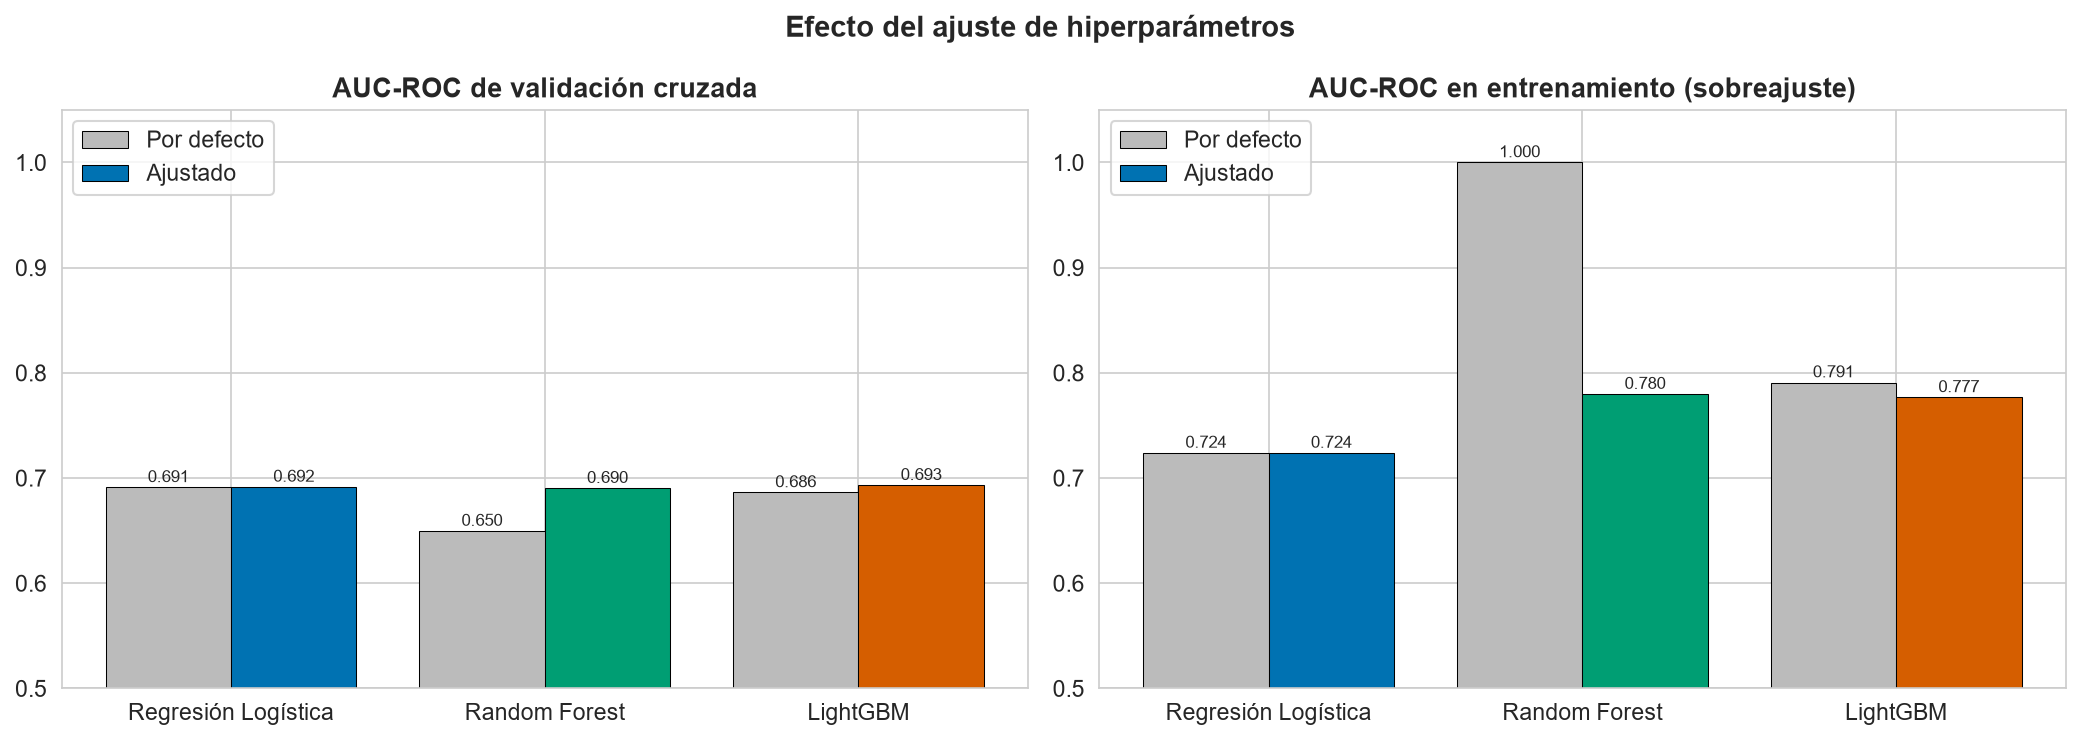

In [8]:
filas = []
for nombre, busqueda in busquedas.items():
    mejor = pd.DataFrame(busqueda.cv_results_).iloc[busqueda.best_index_]
    filas.append({
        'modelo': nombre,
        'auc_cv_defecto': res_defecto[nombre]['auc_cv'],
        'auc_cv_ajustado': busqueda.best_score_,
        'mejora': busqueda.best_score_ - res_defecto[nombre]['auc_cv'],
        'auc_cv_std_ajustado': mejor['std_test_score'],
        'auc_train_defecto': res_defecto[nombre]['auc_train'],
        'auc_train_ajustado': mejor['mean_train_score'],
        'configuraciones_probadas': CONFIG[nombre]['n_iter'],
        'tiempo_busqueda_min': busqueda.tiempo_busqueda_ / 60,
        'mejores_hiperparametros': json.dumps({k.replace('model__', ''): (round(v, 5) if isinstance(v, float) else v)
                                               for k, v in busqueda.best_params_.items()}, default=a_json),
    })
ajuste = pd.DataFrame(filas)
ajuste.round(4).to_csv(TAB_DIR / 'ajuste_hiperparametros.csv', index=False)
display(ajuste.drop(columns='mejores_hiperparametros').round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(ajuste))
for ax, (col_d, col_a, titulo) in zip(axes, [
        ('auc_cv_defecto', 'auc_cv_ajustado', 'AUC-ROC de validación cruzada'),
        ('auc_train_defecto', 'auc_train_ajustado', 'AUC-ROC en entrenamiento (sobreajuste)')]):
    ax.bar(x - 0.2, ajuste[col_d], 0.4, color='#BBBBBB', edgecolor='black', linewidth=0.5, label='Por defecto')
    ax.bar(x + 0.2, ajuste[col_a], 0.4, color=[COLORES[m] for m in ajuste['modelo']],
           edgecolor='black', linewidth=0.5, label='Ajustado')
    for i, (d, a) in enumerate(zip(ajuste[col_d], ajuste[col_a])):
        ax.text(i - 0.2, d + 0.005, f'{d:.3f}', ha='center', fontsize=8)
        ax.text(i + 0.2, a + 0.005, f'{a:.3f}', ha='center', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(ajuste['modelo'])
    ax.set_ylim(0.5, 1.05)
    ax.set_title(titulo, fontweight='bold')
    ax.legend(loc='upper left')
fig.suptitle('Efecto del ajuste de hiperparámetros', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / '18_ajuste_hiperparametros.png')
plt.show()

**Interpretación**:

- **Random Forest es el que más se beneficia del ajuste** (+0.041 de AUC en validación cruzada, de 0.650 a 0.690). Con la configuración por defecto, los árboles crecen hasta memorizar el entrenamiento (AUC 1.000 en entrenamiento). La configuración ajustada lo regulariza: hojas con al menos 167 pares, 20 % de las variables por división y 66 % de la muestra por árbol. Así, el AUC de entrenamiento baja a 0.780 y el de validación sube.
- **LightGBM mejora +0.007** (de 0.686 a 0.693) con una tasa de aprendizaje baja (0.0078) y muchos árboles (1,021), hojas grandes (≥ 387 pares), 40 % de las variables por árbol y regularización L1/L2. Dar más peso a la clase positiva **no** mejoró el AUC (`scale_pos_weight = 1`), algo esperable porque el AUC no depende del umbral.
- **La Regresión Logística prácticamente no cambia** (+0.0004). Su AUC es casi constante para distintos valores de `C`; el mejor (0.0013) está cerca del límite inferior del rango explorado, es decir, prefiere una regularización fuerte, pero con una ganancia despreciable.
- La desviación estándar entre pliegues es pequeña (0.001–0.003), así que las diferencias de ~0.003 entre los modelos ajustados están en el orden del ruido de la validación cruzada.

## 6. Selección del umbral de decisión

Los modelos entregan puntajes de probabilidad. Para las métricas que requieren una clase se elige, para cada modelo, el umbral que **maximiza F1** sobre las predicciones **fuera de pliegue** del conjunto de entrenamiento (cada par se predice con un modelo que no lo vio). Ese umbral se aplica sin cambios a la prueba.

### Ensamble

El ensamble promedia los tres modelos. Como sus puntajes están en escalas distintas (los pesos de clase desplazan las probabilidades), no se promedian las probabilidades sino su **percentil** dentro de la distribución fuera de pliegue de cada modelo (promedio de rangos). El puntaje del ensamble es la posición relativa promedio del par en los tres modelos.

In [9]:
oof = {}
for nombre, busqueda in busquedas.items():
    t0 = time.time()
    oof[nombre] = cross_val_predict(clone(busqueda.best_estimator_), X_train, y_train, cv=FOLDS,
                                    method='predict_proba', n_jobs=1)[:, 1]
    print(f'{nombre:<20} predicciones fuera de pliegue en {time.time() - t0:.0f} s | '
          f'AUC OOF = {roc_auc_score(y_train, oof[nombre]):.4f}')

REFERENCIA = {nombre: np.sort(p) for nombre, p in oof.items()}


def percentil(nombre, p):
    """Posición relativa (0-1) de p en la distribución fuera de pliegue del modelo."""
    ref = REFERENCIA[nombre]
    return np.searchsorted(ref, p, side='right') / len(ref)


def puntaje_ensamble(probas):
    return np.mean([percentil(n, probas[n]) for n in busquedas], axis=0)


oof['Ensamble'] = puntaje_ensamble(oof)
print(f"{'Ensamble':<20} AUC OOF = {roc_auc_score(y_train, oof['Ensamble']):.4f}")


def umbral_f1(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec + rec) > 0)
    i = np.argmax(f1[:-1])
    return float(thr[i]), float(f1[i])


UMBRALES = {}
for nombre in MODELOS:
    UMBRALES[nombre], f1_oof = umbral_f1(y_train, oof[nombre])
    print(f'{nombre:<20} umbral = {UMBRALES[nombre]:.4f} | F1 fuera de pliegue = {f1_oof:.4f}')

Regresión Logística  predicciones fuera de pliegue en 5 s | AUC OOF = 0.6915


Random Forest        predicciones fuera de pliegue en 72 s | AUC OOF = 0.6903


LightGBM             predicciones fuera de pliegue en 23 s | AUC OOF = 0.6931
Ensamble             AUC OOF = 0.6945
Regresión Logística  umbral = 0.6360 | F1 fuera de pliegue = 0.2120
Random Forest        umbral = 0.5754 | F1 fuera de pliegue = 0.2086


LightGBM             umbral = 0.1069 | F1 fuera de pliegue = 0.2145
Ensamble             umbral = 0.8637 | F1 fuera de pliegue = 0.2149


## 7. Evaluación final en el conjunto de prueba

Cada modelo ajustado (reentrenado con todo el conjunto de entrenamiento por `RandomizedSearchCV`) predice el 20 % reservado. Se mide también el tiempo de predicción.

Además de las métricas estándar se reporta la **captura en el 10 % superior**: si el vendedor solo pudiera contactar al 10 % de los compradores con mayor puntaje, qué porcentaje de los recurrentes reales alcanzaría (un modelo aleatorio alcanzaría el 10 %).

In [10]:
proba_test, tiempos = {}, {}
for nombre, busqueda in busquedas.items():
    t0 = time.time()
    proba_test[nombre] = busqueda.best_estimator_.predict_proba(X_test)[:, 1]
    tiempos[nombre] = {'entrenamiento_s': busqueda.refit_time_, 'prediccion_s': time.time() - t0,
                       'busqueda_min': busqueda.tiempo_busqueda_ / 60}
t0 = time.time()
proba_test['Ensamble'] = puntaje_ensamble(proba_test)
tiempos['Ensamble'] = {
    'entrenamiento_s': sum(tiempos[n]['entrenamiento_s'] for n in busquedas),
    'prediccion_s': sum(tiempos[n]['prediccion_s'] for n in busquedas) + time.time() - t0,
    'busqueda_min': sum(tiempos[n]['busqueda_min'] for n in busquedas),
}


def captura_superior(y, p, fraccion=0.10):
    n = int(np.ceil(len(p) * fraccion))
    top = np.argsort(-p)[:n]
    return y[top].sum() / y.sum(), y[top].mean()


def metricas(y, p, umbral):
    pred = (p >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    captura, precision_top = captura_superior(y, p)
    return {
        'auc_roc': roc_auc_score(y, p), 'auc_pr': average_precision_score(y, p),
        'precision': precision_score(y, pred, zero_division=0), 'recall': recall_score(y, pred),
        'f1': f1_score(y, pred), 'accuracy': accuracy_score(y, pred),
        'balanced_accuracy': balanced_accuracy_score(y, pred),
        'captura_top10': captura, 'precision_top10': precision_top,
        'umbral': umbral, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    }


comparacion = pd.DataFrame({n: {**metricas(y_test, proba_test[n], UMBRALES[n]), **tiempos[n],
                                'auc_cv': roc_auc_score(y_train, oof[n])} for n in MODELOS}).T
comparacion.index.name = 'modelo'
comparacion.round(4).to_csv(TAB_DIR / 'comparacion_modelos.csv')
cols_vista = ['auc_roc', 'auc_pr', 'precision', 'recall', 'f1', 'captura_top10', 'accuracy',
              'auc_cv', 'entrenamiento_s', 'prediccion_s']
display(comparacion[cols_vista].astype(float).round(4))
print(f'\nReferencia — aleatorio: AUC-ROC 0.500, AUC-PR {base_prev:.4f}, captura top 10 % = 0.100')
print(f'Referencia — m_repeat_buyer_rate_log sola: AUC-ROC {base_var_auc:.4f}, AUC-PR {base_var_ap:.4f}')

,auc_roc,auc_pr,precision,recall,f1,captura_top10,accuracy,auc_cv,entrenamiento_s,prediccion_s
modelo,,,,,,,,,,
Regresión Logística,0.6892,0.1367,0.1561,0.3182,0.2094,0.2671,0.8531,0.6915,1.1833,0.0493
Random Forest,0.6857,0.1343,0.1463,0.3577,0.2076,0.2690,0.8331,0.6903,19.0341,0.2447
LightGBM,0.6893,0.1389,0.1563,0.3179,0.2096,0.2708,0.8534,0.6931,4.7941,0.3353
Ensamble,0.6907,0.1388,0.1538,0.3361,0.2110,0.2734,0.8464,0.6945,25.0115,0.6471



Referencia — aleatorio: AUC-ROC 0.500, AUC-PR 0.0611, captura top 10 % = 0.100
Referencia — m_repeat_buyer_rate_log sola: AUC-ROC 0.6139, AUC-PR 0.0957


## 8. Comparación gráfica de los modelos

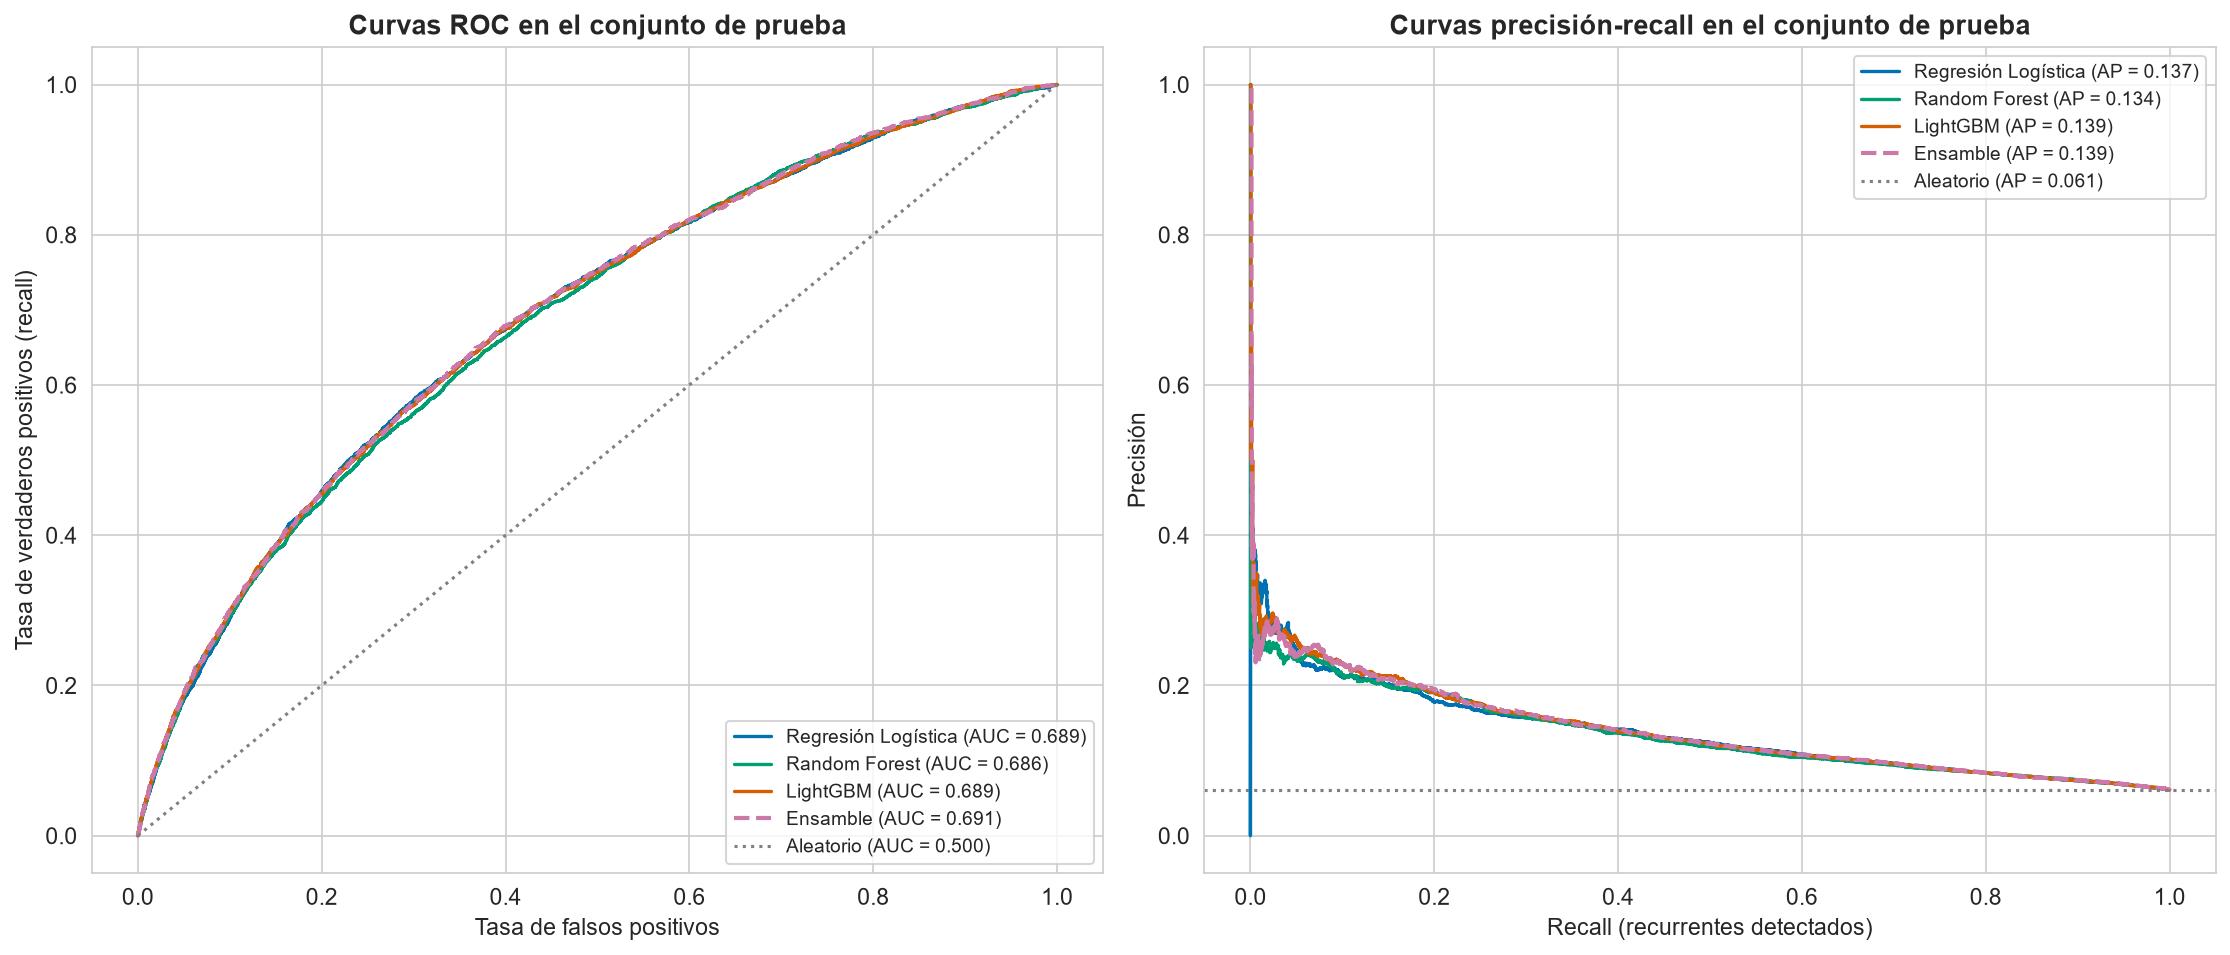

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for nombre in MODELOS:
    fpr, tpr, _ = roc_curve(y_test, proba_test[nombre])
    axes[0].plot(fpr, tpr, color=COLORES[nombre], linewidth=2 if nombre == 'Ensamble' else 1.6,
                 linestyle='--' if nombre == 'Ensamble' else '-',
                 label=f"{nombre} (AUC = {comparacion.loc[nombre, 'auc_roc']:.3f})")
    prec, rec, _ = precision_recall_curve(y_test, proba_test[nombre])
    axes[1].plot(rec, prec, color=COLORES[nombre], linewidth=2 if nombre == 'Ensamble' else 1.6,
                 linestyle='--' if nombre == 'Ensamble' else '-',
                 label=f"{nombre} (AP = {comparacion.loc[nombre, 'auc_pr']:.3f})")
axes[0].plot([0, 1], [0, 1], color='gray', linestyle=':', label='Aleatorio (AUC = 0.500)')
axes[0].set_xlabel('Tasa de falsos positivos')
axes[0].set_ylabel('Tasa de verdaderos positivos (recall)')
axes[0].set_title('Curvas ROC en el conjunto de prueba', fontweight='bold')
axes[1].axhline(base_prev, color='gray', linestyle=':', label=f'Aleatorio (AP = {base_prev:.3f})')
axes[1].set_xlabel('Recall (recurrentes detectados)')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Curvas precisión-recall en el conjunto de prueba', fontweight='bold')
for ax in axes:
    ax.legend(loc='lower right' if ax is axes[0] else 'upper right', fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / '19_curvas_roc_pr.png')
plt.show()

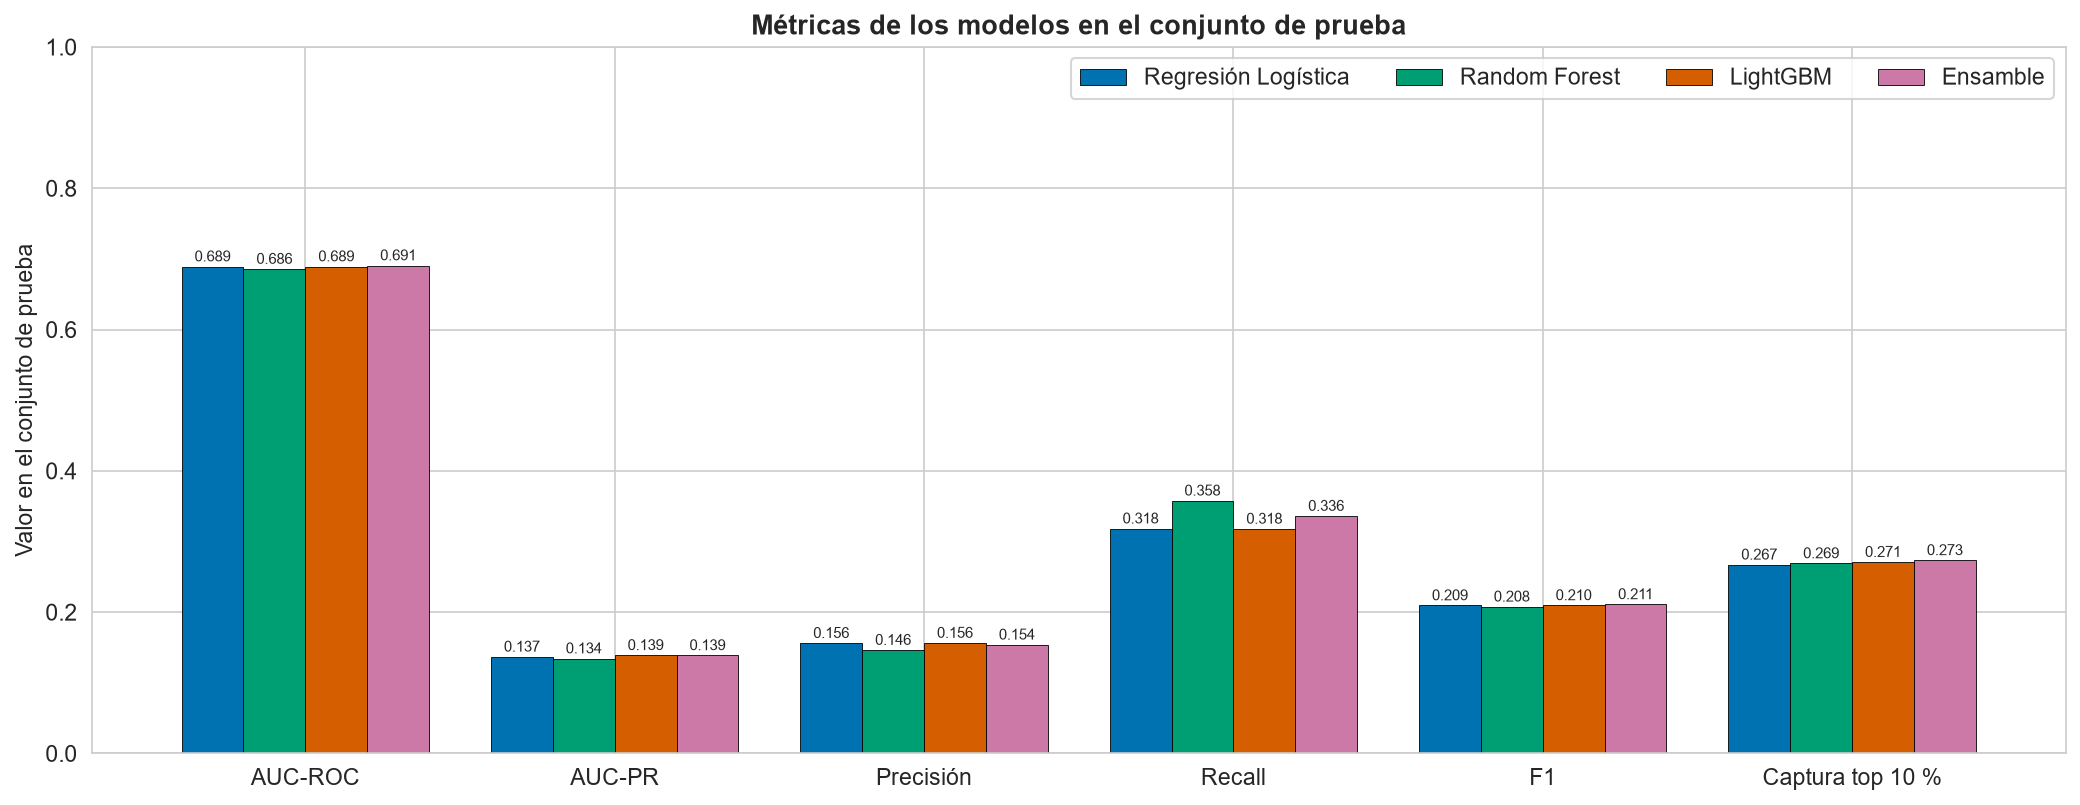

In [12]:
metricas_graf = {'auc_roc': 'AUC-ROC', 'auc_pr': 'AUC-PR', 'precision': 'Precisión',
                 'recall': 'Recall', 'f1': 'F1', 'captura_top10': 'Captura top 10 %'}
fig, ax = plt.subplots(figsize=(14, 5.5))
ancho = 0.2
x = np.arange(len(metricas_graf))
for i, nombre in enumerate(MODELOS):
    vals = comparacion.loc[nombre, list(metricas_graf)].astype(float)
    barras = ax.bar(x + (i - 1.5) * ancho, vals, ancho, color=COLORES[nombre], label=nombre,
                    edgecolor='black', linewidth=0.4)
    ax.bar_label(barras, fmt='%.3f', fontsize=7, padding=1)
ax.set_xticks(x)
ax.set_xticklabels(metricas_graf.values())
ax.set_ylim(0, 1)
ax.set_ylabel('Valor en el conjunto de prueba')
ax.set_title('Métricas de los modelos en el conjunto de prueba', fontweight='bold')
ax.legend(ncol=4, loc='upper right')
plt.tight_layout()
fig.savefig(FIG_DIR / '20_metricas_modelos.png')
plt.show()

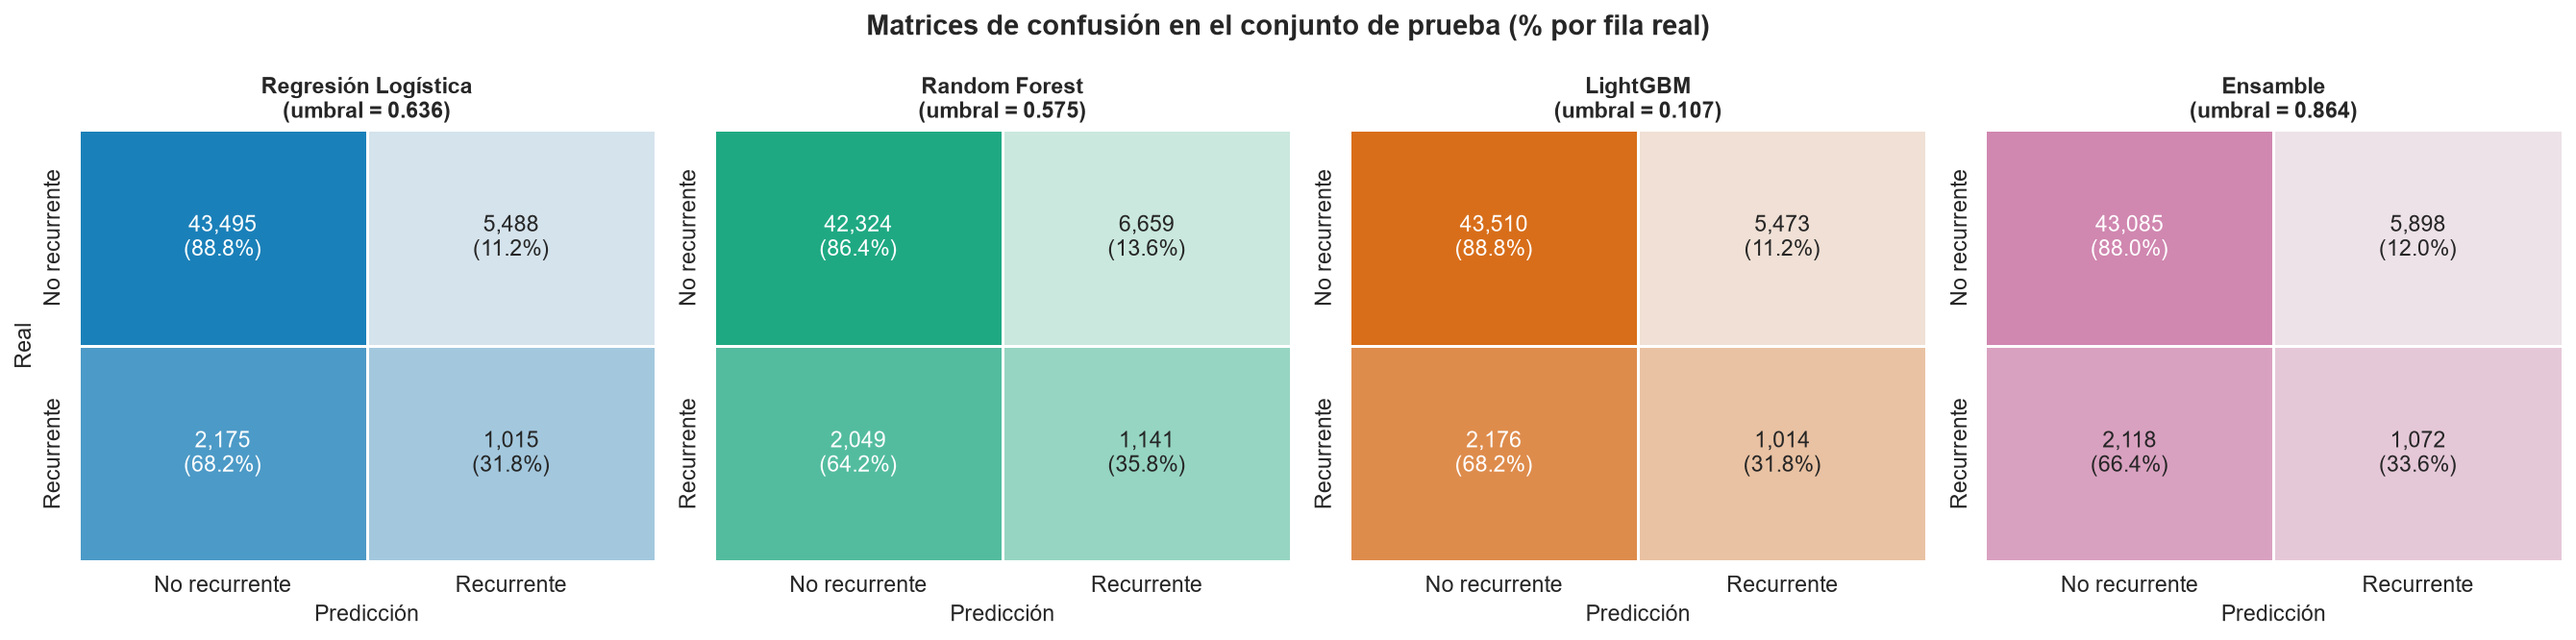

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, nombre in zip(axes, MODELOS):
    fila = comparacion.loc[nombre]
    cm = np.array([[fila['tn'], fila['fp']], [fila['fn'], fila['tp']]], dtype=int)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    anot = np.array([[f'{cm[i, j]:,}\n({cm_pct[i, j]:.1f}%)' for j in range(2)] for i in range(2)])
    sns.heatmap(cm_pct, annot=anot, fmt='', cmap=sns.light_palette(COLORES[nombre], as_cmap=True),
                cbar=False, ax=ax, vmin=0, vmax=100, linewidths=0.5, linecolor='white')
    ax.set_xticklabels(['No recurrente', 'Recurrente'])
    ax.set_yticklabels(['No recurrente', 'Recurrente'], rotation=90, va='center')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real' if nombre == MODELOS[0] else '')
    ax.set_title(f"{nombre}\n(umbral = {fila['umbral']:.3f})", fontweight='bold', fontsize=11)
fig.suptitle('Matrices de confusión en el conjunto de prueba (% por fila real)', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / '21_matrices_confusion.png')
plt.show()

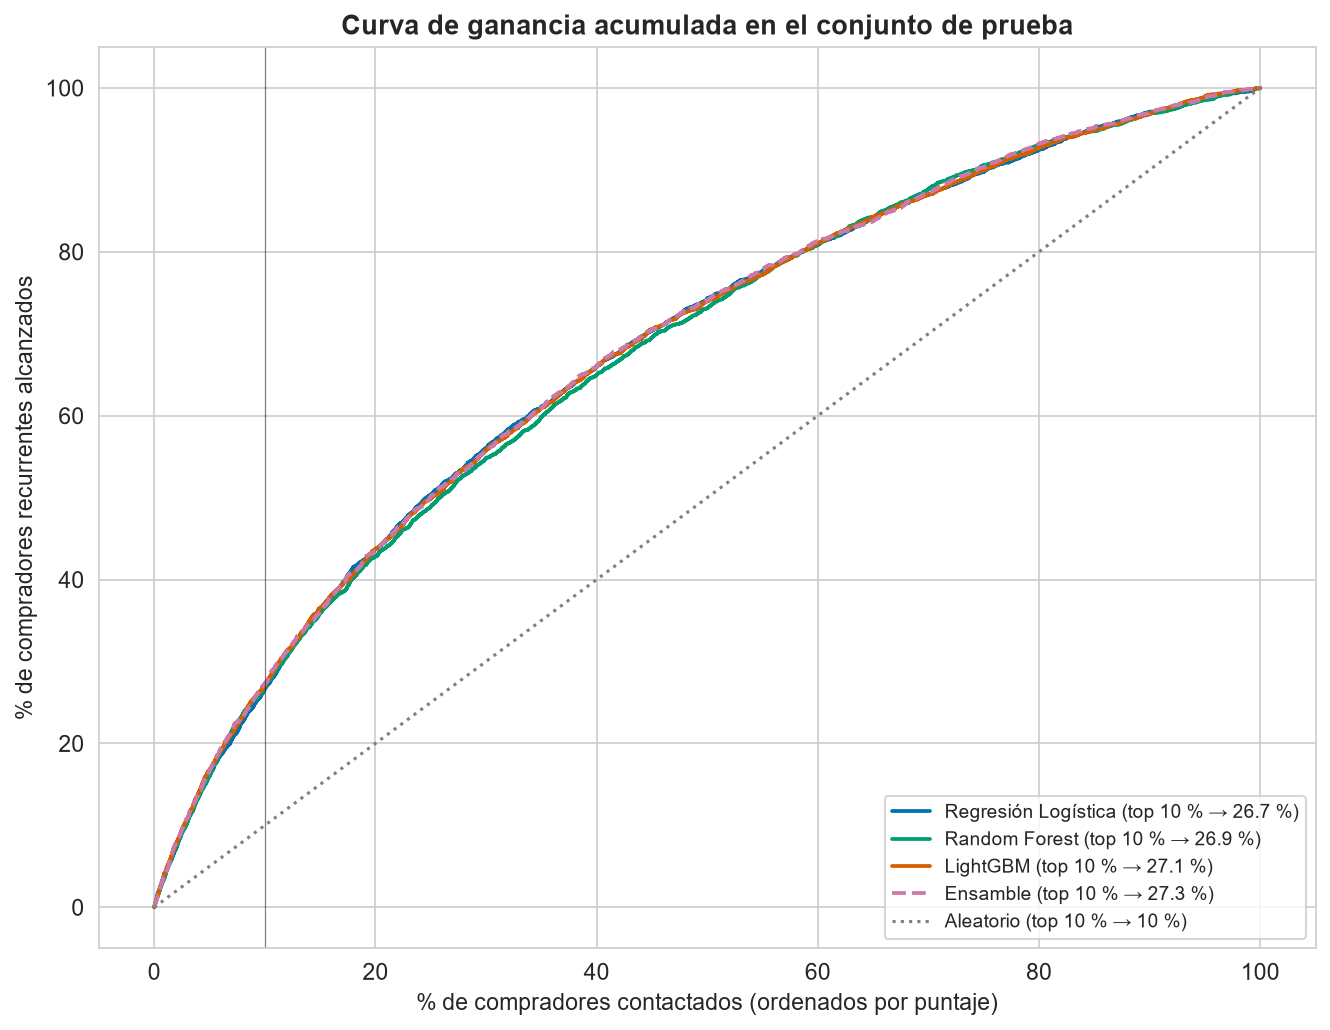

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
for nombre in MODELOS:
    orden = np.argsort(-proba_test[nombre])
    capturados = np.cumsum(y_test[orden]) / y_test.sum()
    fraccion = np.arange(1, len(orden) + 1) / len(orden)
    ax.plot(fraccion * 100, capturados * 100, color=COLORES[nombre],
            linestyle='--' if nombre == 'Ensamble' else '-', linewidth=1.8,
            label=f"{nombre} (top 10 % → {comparacion.loc[nombre, 'captura_top10'] * 100:.1f} %)")
ax.plot([0, 100], [0, 100], color='gray', linestyle=':', label='Aleatorio (top 10 % → 10 %)')
ax.axvline(10, color='black', linewidth=0.6, alpha=0.5)
ax.set_xlabel('% de compradores contactados (ordenados por puntaje)')
ax.set_ylabel('% de compradores recurrentes alcanzados')
ax.set_title('Curva de ganancia acumulada en el conjunto de prueba', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / '22_curva_ganancia.png')
plt.show()

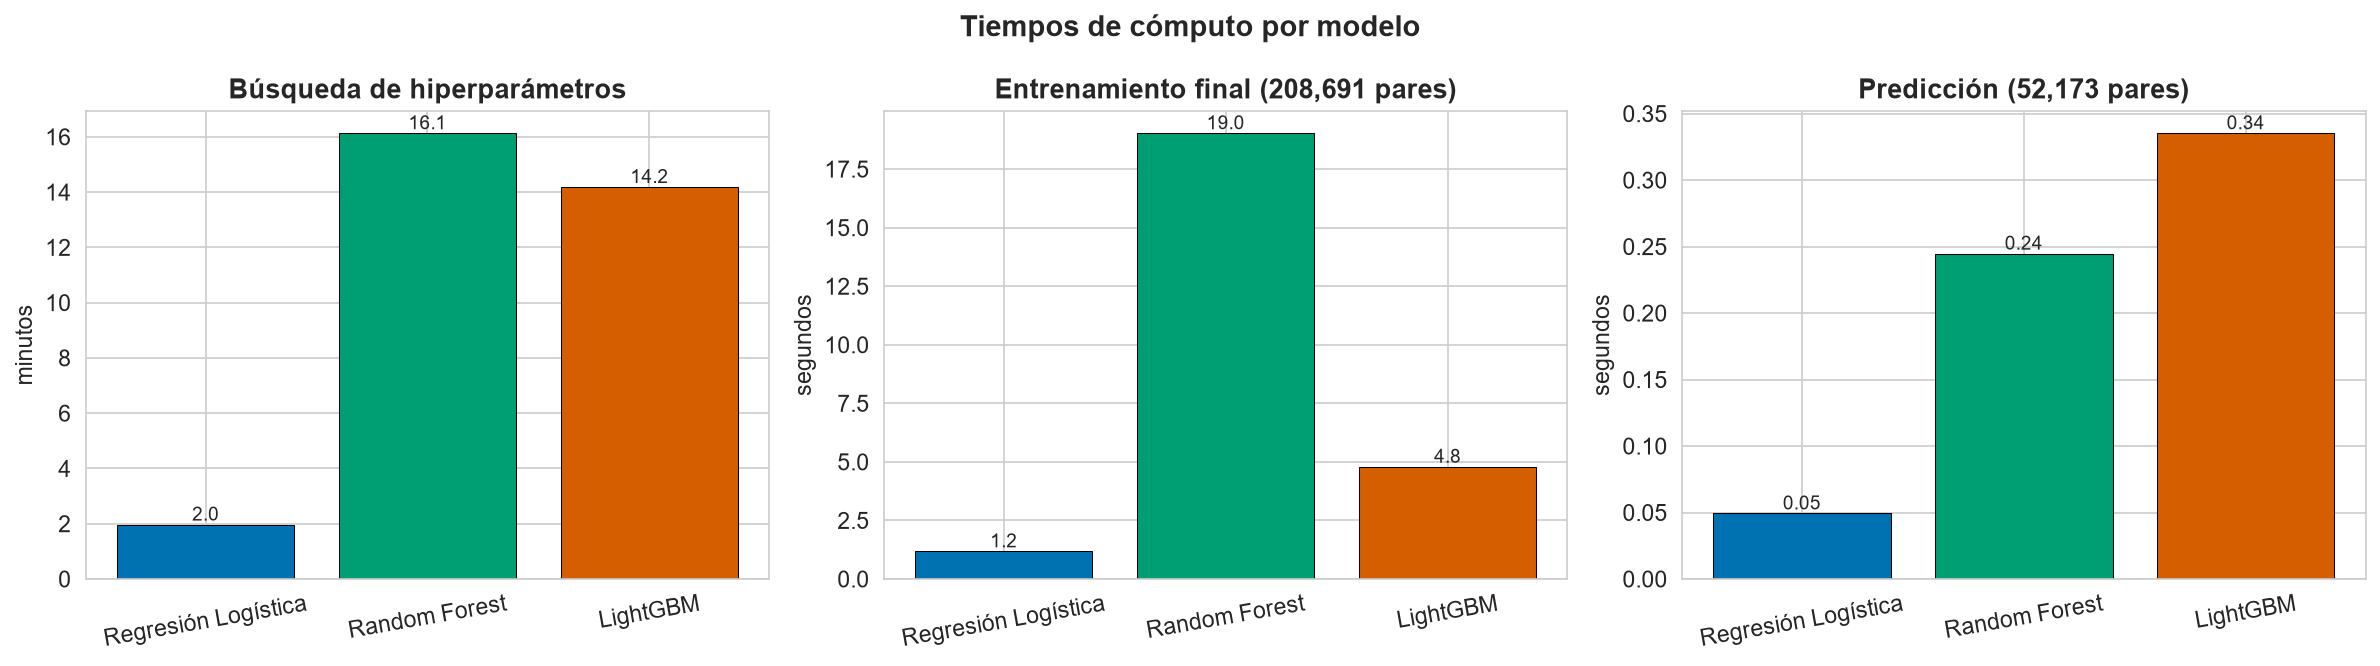

In [15]:
t = comparacion[['entrenamiento_s', 'prediccion_s', 'busqueda_min']].astype(float).loc[MODELOS[:3]]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (col, titulo, unidad) in zip(axes, [
        ('busqueda_min', 'Búsqueda de hiperparámetros', 'minutos'),
        ('entrenamiento_s', 'Entrenamiento final (208,691 pares)', 'segundos'),
        ('prediccion_s', 'Predicción (52,173 pares)', 'segundos')]):
    barras = ax.bar(t.index, t[col], color=[COLORES[m] for m in t.index], edgecolor='black', linewidth=0.5)
    ax.bar_label(barras, fmt='%.2f' if col == 'prediccion_s' else '%.1f', fontsize=9)
    ax.set_ylabel(unidad)
    ax.set_title(titulo, fontweight='bold')
    ax.tick_params(axis='x', rotation=10)
fig.suptitle('Tiempos de cómputo por modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / '23_tiempos_modelos.png')
plt.show()

## 9. Importancia de las variables

Cada algoritmo mide la importancia a su manera:
- **Regresión Logística**: coeficiente de cada variable estandarizada (signo = dirección del efecto sobre la probabilidad de recompra).
- **Random Forest**: reducción media de impureza (Gini).
- **LightGBM**: ganancia total aportada por las divisiones que usan la variable.

Las importancias de los árboles se normalizan para sumar 100 %.

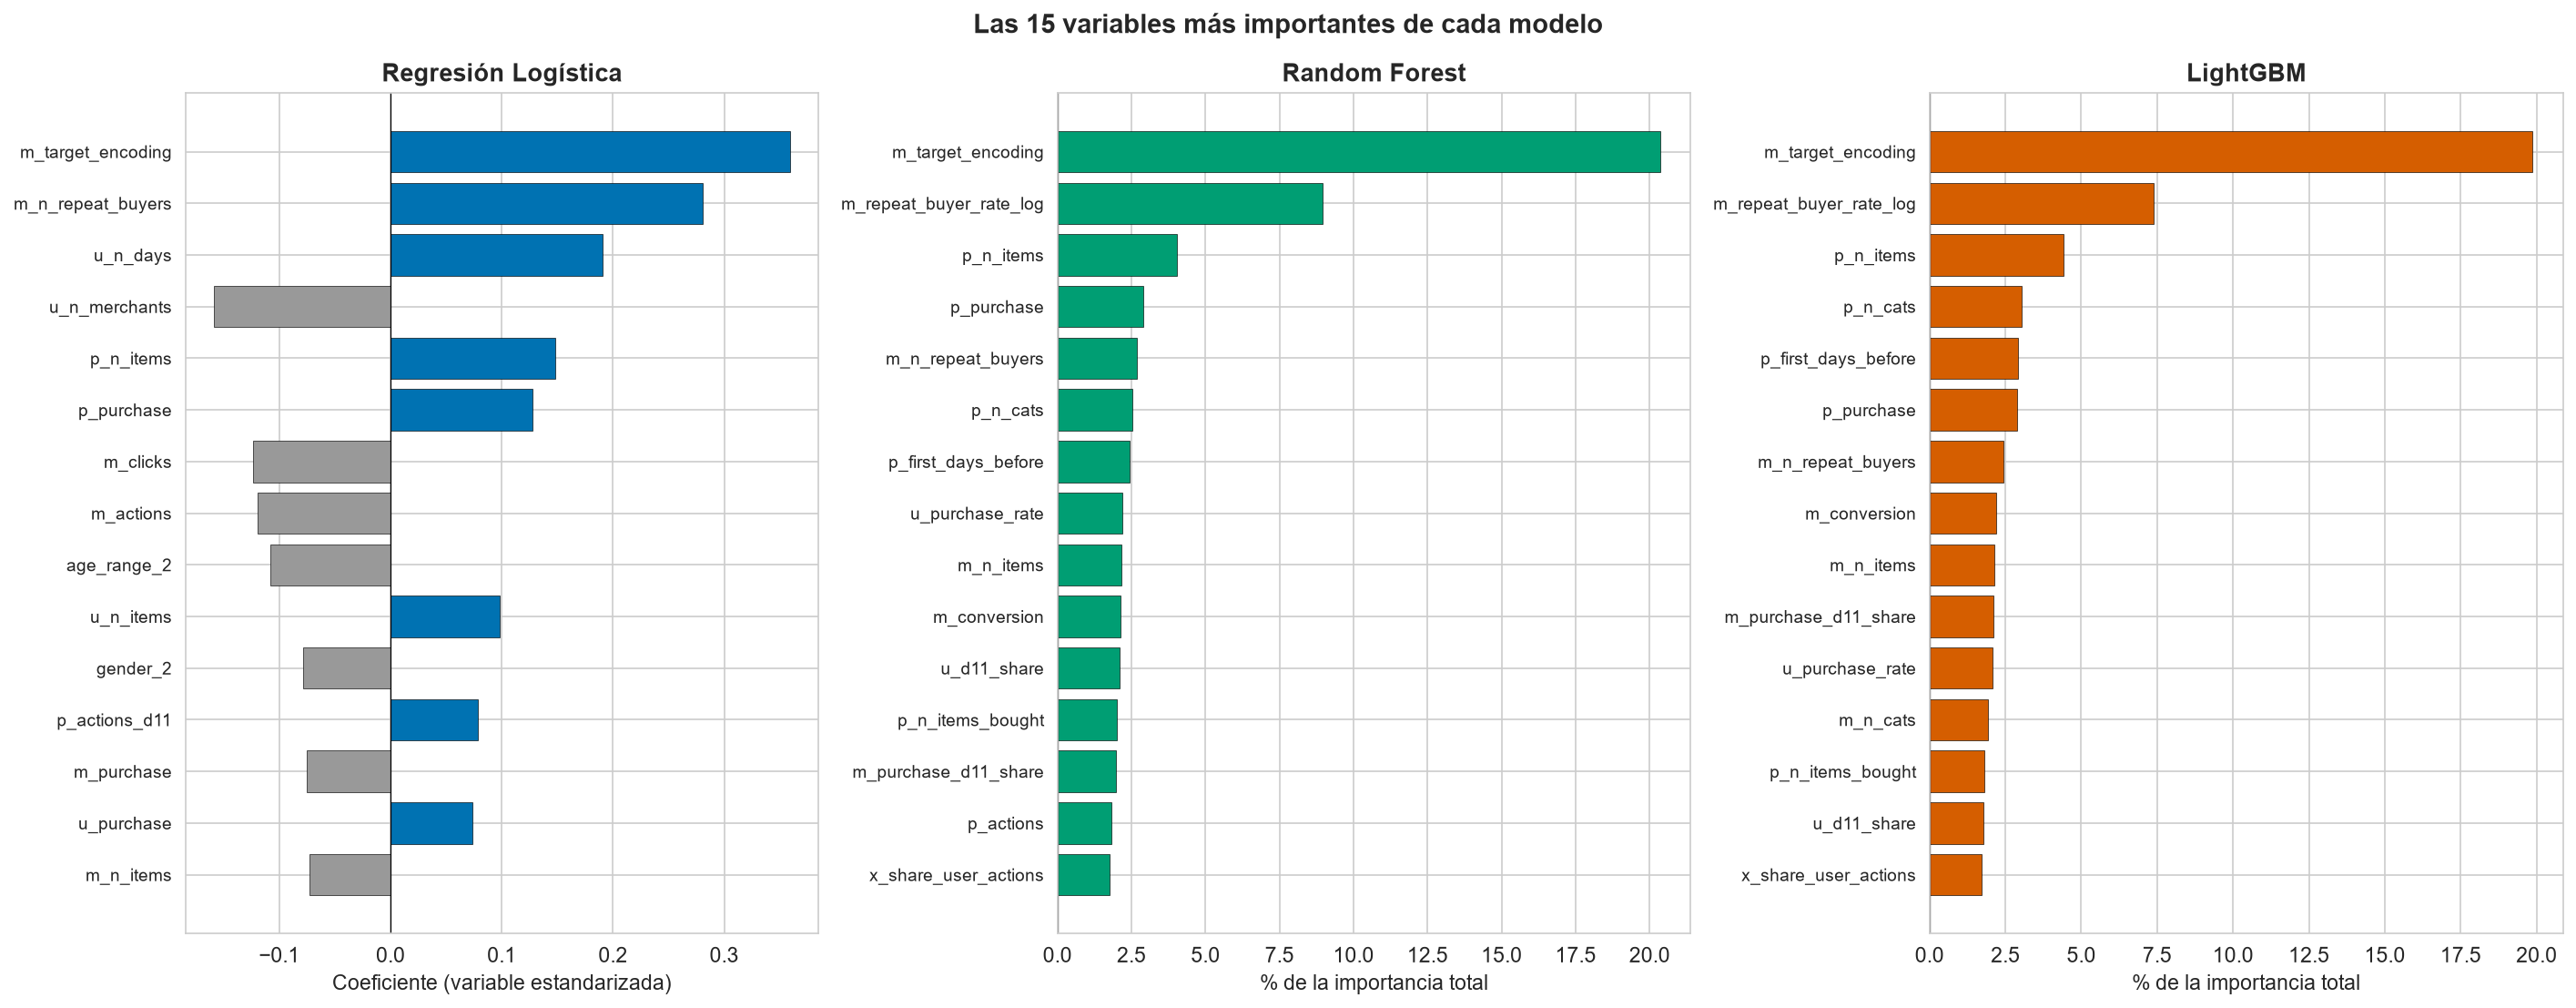

Variables con mejor ranking promedio entre los tres modelos:


,Regresión Logística,Random Forest,LightGBM,ranking_promedio
m_target_encoding,0.359,20.370,19.871,1.000
p_n_items,0.149,4.029,4.430,3.667
m_n_repeat_buyers,0.281,2.694,2.445,4.667
p_purchase,0.128,2.898,2.876,5.333
p_n_cats,0.071,2.534,3.022,9.333
p_first_days_before,0.072,2.445,2.903,9.667
m_n_items,-0.073,2.163,2.127,11.000
m_repeat_buyer_rate_log,0.048,8.959,7.384,12.333
u_n_days,0.191,1.342,1.484,14.333
u_n_merchants,-0.159,1.166,1.568,18.000


In [16]:
def nombres_salida(pipe):
    nombres = pipe.named_steps['prep'].get_feature_names_out()
    return [n.split('__', 1)[1].replace('merchant_id', 'm_target_encoding') for n in nombres]


imp = {}
lr_pipe = busquedas['Regresión Logística'].best_estimator_
imp['Regresión Logística'] = pd.Series(lr_pipe.named_steps['model'].coef_[0], index=nombres_salida(lr_pipe))
rf_pipe = busquedas['Random Forest'].best_estimator_
imp['Random Forest'] = pd.Series(rf_pipe.named_steps['model'].feature_importances_ * 100,
                                 index=nombres_salida(rf_pipe))
lgb_pipe = busquedas['LightGBM'].best_estimator_
ganancia = lgb_pipe.named_steps['model'].booster_.feature_importance(importance_type='gain')
imp['LightGBM'] = pd.Series(ganancia / ganancia.sum() * 100, index=nombres_salida(lgb_pipe))

tabla_imp = pd.DataFrame(imp).fillna(0)
# Ranking promedio solo entre variables presentes en los tres modelos
# (las columnas one-hot de edad y género existen solo en la Regresión Logística)
tabla_imp['ranking_promedio'] = pd.concat([imp['Regresión Logística'].abs().rank(ascending=False),
                                           imp['Random Forest'].rank(ascending=False),
                                           imp['LightGBM'].rank(ascending=False)], axis=1).mean(axis=1, skipna=False)
tabla_imp.sort_values('ranking_promedio').round(4).to_csv(TAB_DIR / 'importancia_variables.csv')

fig, axes = plt.subplots(1, 3, figsize=(19, 7.5))
for ax, nombre in zip(axes, ['Regresión Logística', 'Random Forest', 'LightGBM']):
    s = imp[nombre]
    top = s.reindex(s.abs().sort_values(ascending=False).index[:15]).iloc[::-1]
    colores = [COLORES[nombre] if v >= 0 else '#999999' for v in top] if nombre == 'Regresión Logística' \
        else COLORES[nombre]
    ax.barh(top.index, top.values, color=colores, edgecolor='black', linewidth=0.3)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('Coeficiente (variable estandarizada)' if nombre == 'Regresión Logística'
                  else '% de la importancia total')
    ax.tick_params(axis='y', labelsize=9)
fig.suptitle('Las 15 variables más importantes de cada modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / '24_importancia_variables.png')
plt.show()

print('Variables con mejor ranking promedio entre los tres modelos:')
display(tabla_imp.sort_values('ranking_promedio').head(15).round(3))

**Interpretación**:

- **La tasa de recompra del vendedor (`m_target_encoding`) es la variable más importante en los tres modelos**: aporta ~20 % de la importancia en Random Forest y LightGBM y tiene el mayor coeficiente en la Regresión Logística. Le sigue la fidelidad histórica del vendedor sin etiqueta (`m_repeat_buyer_rate_log` en los árboles, `m_n_repeat_buyers` en la regresión). **Retener depende en gran medida de quién es el vendedor.**
- Después vienen las variables de **la relación usuario-vendedor**: diversidad (`p_n_items`, `p_n_cats`), compras del 11/11 (`p_purchase`) y antigüedad de la relación (`p_first_days_before`). Esto coincide con el EDA y con el AUC individual del notebook 02.
- En la Regresión Logística algunos coeficientes son **negativos**, controlando por las demás variables:
  - `u_n_merchants`: los usuarios que reparten su actividad entre muchos vendedores son menos fieles a cada uno.
  - `m_clicks` y `m_actions`: los vendedores con mucho tráfico de navegación retienen proporcionalmente menos.
- Las **variables demográficas tienen un peso bajo** en los tres modelos, coherente con su débil asociación en el EDA.

## 10. Exportación de modelos y artefactos para la aplicación

Se guardan los tres `Pipeline` completos (preprocesamiento + modelo), los umbrales, las distribuciones de referencia del ensamble y las predicciones sobre la prueba, que la aplicación usará para las gráficas interactivas de rendimiento.

In [17]:
archivos = {}
for nombre, busqueda in busquedas.items():
    ruta = MODEL_DIR / f'modelo_{CLAVE[nombre]}.joblib'
    joblib.dump(busqueda.best_estimator_, ruta, compress=3)
    archivos[nombre] = ruta.name

np.savez_compressed(MODEL_DIR / 'referencia_ensamble.npz',
                    **{CLAVE[n]: REFERENCIA[n] for n in REFERENCIA})

pred = test[['user_id', 'merchant_id', 'label']].copy()
for nombre in MODELOS:
    pred[f'p_{CLAVE[nombre]}'] = proba_test[nombre]
pred.to_parquet(MODEL_DIR / 'predicciones_prueba.parquet', index=False)

metadata = {
    'creado': pd.Timestamp.now().isoformat(timespec='seconds'),
    'features': FEATURES, 'num': NUM, 'cat': CAT,
    'modelos': {nombre: {
        'clave': CLAVE[nombre],
        'archivo': archivos.get(nombre),
        'umbral': UMBRALES[nombre],
        'mejores_hiperparametros': {k.replace('model__', ''): v for k, v in busquedas[nombre].best_params_.items()}
        if nombre in busquedas else None,
        'metricas_prueba': {k: float(v) for k, v in comparacion.loc[nombre].items()},
    } for nombre in MODELOS},
    'ensamble': 'Promedio de percentiles de LR, RF y LightGBM respecto a su distribución fuera de pliegue '
                '(referencia_ensamble.npz)',
    'prevalencia_entrenamiento': float(y_train.mean()),
}
(MODEL_DIR / 'metadata.json').write_text(json.dumps(metadata, ensure_ascii=False, indent=2, default=a_json),
                                         encoding='utf-8')

for f in sorted(MODEL_DIR.iterdir()):
    print(f'{f.name:<35} {f.stat().st_size / 1e6:8.1f} MB')

metadata.json                            0.0 MB
modelo_lgbm.joblib                       2.1 MB
modelo_lr.joblib                         0.0 MB
modelo_rf.joblib                        18.1 MB
predicciones_prueba.parquet              2.5 MB
referencia_ensamble.npz                  3.7 MB


## 11. Conclusiones del modelado

1. **Todos los modelos superan la meta.** El AUC-ROC en la prueba va de 0.686 (Random Forest) a 0.691 (Ensamble), por encima de la meta de 0.65, del clasificador aleatorio (0.5) y de la mejor variable individual (0.614). El AUC-PR (0.134–0.139) es más del doble de la prevalencia (0.061).
2. **Valor práctico.** Si el vendedor contactara solo al 10 % de los compradores con mayor puntaje, alcanzaría al ~27 % de los recurrentes, 2.7 veces más que eligiendo al azar. Con el umbral que maximiza F1, cada modelo identifica entre el 32 % y el 36 % de los recurrentes con una precisión de ~15 %, 2.5 veces la tasa base.
3. **El problema es difícil.** F1 ronda 0.21: separar a los recurrentes es complicado con información de comportamiento previo, lo que coincide con el AUC cercano a 0.70 que reportó la solución ganadora de la competencia (Liu et al., 2016). La exactitud (83–85 %) es engañosa porque no supera al clasificador trivial (93.9 %), y por eso no se usa para comparar.
4. **Los modelos rinden prácticamente igual.** Las diferencias de AUC (≤ 0.005) son del orden del ruido de validación cruzada. El límite lo pone la información disponible, no el algoritmo, lo que concuerda con la literatura: la ingeniería de variables pesa más que la elección del modelo.
5. **Selección.**
   - **LightGBM** es el **modelo principal recomendado**: mejor AUC de validación cruzada (0.693) con la menor variabilidad entre pliegues (±0.001), mejor AUC-PR en prueba (0.139), entrenamiento en ~5 s y robustez frente a variables sesgadas sin necesidad de transformarlas.
   - El **Ensamble** da el mejor AUC-ROC en prueba (0.691), pero la ganancia (+0.001) no compensa el costo de mantener tres modelos.
   - La **Regresión Logística** empata con LightGBM en AUC-ROC en prueba (0.689) y es la más rápida e interpretable. Es la mejor opción si se necesita explicar el efecto de cada variable.
   - **Random Forest** es el más lento de ajustar (16 min con solo 12 configuraciones) y el de menor AUC, aunque tiene el mayor recall con su umbral (0.358).
6. **Lo que más predice la recompra es el vendedor**: su tasa histórica de recompra y la fidelidad de su clientela. Después viene la profundidad de la relación del usuario con ese vendedor.